# Active Inference Demo: Cue Chaining (JAX)

This tutorial ports the legacy cue-chaining demo to modern JAX `pymdp` using:

- `CueChainingEnv` (a reusable `PymdpEnv` subclass)
- `Agent` for inference + planning
- `rollout()` for a scanned active-inference loop

The task is a two-stage epistemic chain:

1. Visit **Cue 1** to learn which **Cue 2** location is informative.
2. Visit that **Cue 2** location to learn which reward location is correct.
3. Exploit by moving to the rewarding location.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import pandas as pd

from pymdp.agent import Agent
from pymdp.envs.cue_chaining import CueChainingEnv
from pymdp.envs.rollout import rollout

## 1) Build the Cue-Chaining Environment

We fix the hidden cue and reward condition for interpretability.

In [2]:
env = CueChainingEnv(
    grid_shape=(5, 7),
    start_location=(0, 0),
    cue1_location=(2, 0),
    cue2_locations=((0, 2), (1, 3), (3, 3), (4, 2)),
    reward_locations=((1, 5), (3, 5)),
    cue2_state=3,       # active cue2 is L4
    reward_condition=1, # reward at second reward location
)

print("A shapes:", [a.shape for a in env.A])
print("B shapes:", [b.shape for b in env.B])
print("D shapes:", [d.shape for d in env.D])

A shapes: [(35, 35), (5, 35, 4), (3, 35, 4, 2), (3, 35, 2)]
B shapes: [(35, 35, 5), (4, 4, 1), (2, 2, 1)]
D shapes: [(35,), (4,), (2,)]


## 2) Create the Agent (Generative Model)

We keep the legacy cue-chaining prior structure:

- The agent is certain about its **start location**.
- The agent is uncertain (uniform) over latent **cue2 state** and **reward condition**.

This lets short-horizon planning (`policy_len=4`) still prioritize epistemic actions (visiting cue1, then cue2).


In [3]:
C = [jnp.zeros((a.shape[0],), dtype=jnp.float32) for a in env.A]
C[3] = C[3].at[1].set(3.0)
C[3] = C[3].at[2].set(-6.0)

# Legacy-style prior: known initial location, uncertain latent context.
D_agent = [
    env.D[0],
    jnp.ones_like(env.D[1]) / env.D[1].shape[0],
    jnp.ones_like(env.D[2]) / env.D[2].shape[0],
]

agent = Agent(
    A=env.A,
    B=env.B,
    C=C,
    D=D_agent,
    A_dependencies=env.A_dependencies,
    B_dependencies=env.B_dependencies,
    policy_len=4,
    action_selection='deterministic',
    batch_size=1,
)

print("num_states:", agent.num_states)
print("num_obs:", agent.num_obs)
print("num_controls:", agent.num_controls)
print("agent D shapes:", [d.shape for d in D_agent])


num_states: [35, 4, 2]
num_obs: [35, 5, 3, 3]
num_controls: [5, 1, 1]
agent D shapes: [(35,), (4,), (2,)]


/var/folders/_f/1qqqnkyd5k5g2b1pgfwzzrqm0000gn/T/ipykernel_92050/3369534931.py:12: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(


## 3) Run `rollout()`

In [4]:
T = 10
_, info = rollout(agent, env, num_timesteps=T, rng_key=jr.PRNGKey(0))

print("action shape:", info["action"].shape)
print("location observation shape:", info["observation"][0].shape)
print("reward observation shape:", info["observation"][3].shape)

action shape: (1, 11, 3)
location observation shape: (1, 11, 1)
reward observation shape: (1, 11, 1)


## 4) Decode Observations and Actions

In [5]:
records = []
for t in range(T + 1):
    loc_obs = int(info["observation"][0][0, t, 0])
    cue1_obs = int(info["observation"][1][0, t, 0])
    cue2_obs = int(info["observation"][2][0, t, 0])
    rew_obs = int(info["observation"][3][0, t, 0])
    action_idx = int(info["action"][0, t, 0])

    records.append(
        {
            "t": t,
            "loc": env.index_to_coords(loc_obs),
            "cue1_obs": env.cue1_obs_names[cue1_obs],
            "cue2_obs": env.cue2_obs_names[cue2_obs],
            "reward_obs": env.reward_obs_names[rew_obs],
            "action": env.ACTION_LABELS[action_idx],
        }
    )

trajectory_df = pd.DataFrame(records)
trajectory_df

,t,loc,cue1_obs,cue2_obs,reward_obs,action
0,0,"(0, 0)",Null,Null,Null,DOWN
1,1,"(1, 0)",Null,Null,Null,DOWN
2,2,"(2, 0)",L4,Null,Null,DOWN
3,3,"(3, 0)",Null,Null,Null,DOWN
4,4,"(4, 0)",Null,Null,Null,RIGHT
5,5,"(4, 1)",Null,Null,Null,RIGHT
6,6,"(4, 2)",Null,reward_on_bottom,Null,UP
7,7,"(3, 2)",Null,Null,Null,RIGHT
8,8,"(3, 3)",Null,Null,Null,RIGHT
9,9,"(3, 4)",Null,Null,Null,RIGHT


## 5) Visualize the trajectory

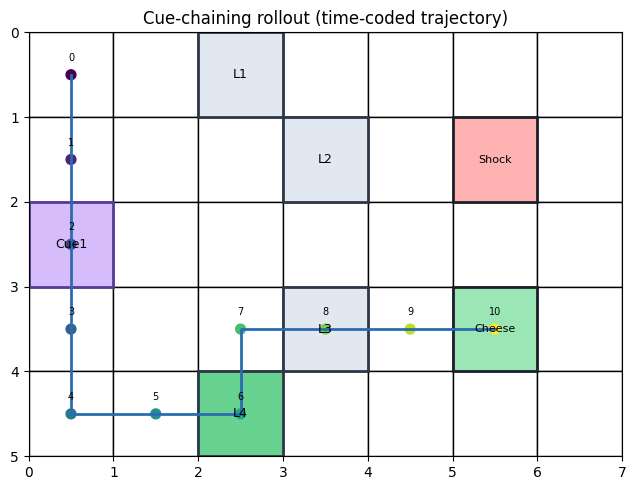

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
rows, cols = env.grid_shape

for r in range(rows):
    for c in range(cols):
        ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor="white", edgecolor="black", linewidth=1))

c1r, c1c = env.cue1_location
ax.add_patch(plt.Rectangle((c1c, c1r), 1, 1, facecolor="#d6bcfa", edgecolor="#553c9a", linewidth=2))
ax.text(c1c + 0.5, c1r + 0.5, "Cue1", ha="center", va="center", fontsize=9)

active_cue_idx = int(info["env_state"][1][0, 0])
for i, (r, c) in enumerate(env.cue2_locations):
    color = "#68d391" if i == active_cue_idx else "#e2e8f0"
    ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=color, edgecolor="#2d3748", linewidth=2))
    ax.text(c + 0.5, r + 0.5, env.cue2_names[i], ha="center", va="center", fontsize=9)

true_reward_state = int(info["env_state"][2][0, 0])
for i, (r, c) in enumerate(env.reward_locations):
    is_reward = i == true_reward_state
    face = "#9ae6b4" if is_reward else "#feb2b2"
    label = "Cheese" if is_reward else "Shock"
    ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=face, edgecolor="#1a202c", linewidth=2))
    ax.text(c + 0.5, r + 0.5, label, ha="center", va="center", fontsize=8)

coords = [env.index_to_coords(int(info["observation"][0][0, t, 0])) for t in range(T + 1)]
xs = [c + 0.5 for _, c in coords]
ys = [r + 0.5 for r, _ in coords]
ax.plot(xs, ys, color="#2b6cb0", linewidth=2)
ax.scatter(xs, ys, c=range(T + 1), cmap="viridis", s=50)

for t, (x, y) in enumerate(zip(xs, ys)):
    ax.text(x, y - 0.2, str(t), ha="center", va="center", fontsize=7)

ax.set_xlim(0, cols)
ax.set_ylim(rows, 0)
ax.set_aspect("equal")
ax.set_title("Cue-chaining rollout (time-coded trajectory)")
ax.set_xticks(range(cols + 1))
ax.set_yticks(range(rows + 1))
plt.tight_layout()
plt.show()

This reusable environment can now be used directly in future planning and docs demos.